In [35]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random

# Theo CT nghiệm



In [ ]:
# height (cm)
X = np.array([[147, 150, 153, 158, 163, 165, 168, 170, 173, 175, 178, 180, 183]]).T
# weight (kg)
y = np.array([[ 49, 50, 51,  54, 58, 59, 60, 62, 63, 64, 66, 67, 68]]).T

one = np.ones((X.shape[0], 1))
Xbar = np.concatenate((one, X), axis=1)


In [ ]:
A = np.dot(Xbar.T, Xbar)
b = np.dot(Xbar.T, y)
w = np.dot(np.linalg.pinv(A), b)

print(f'w = {w}')

w = [[-33.73541021]
 [  0.55920496]]


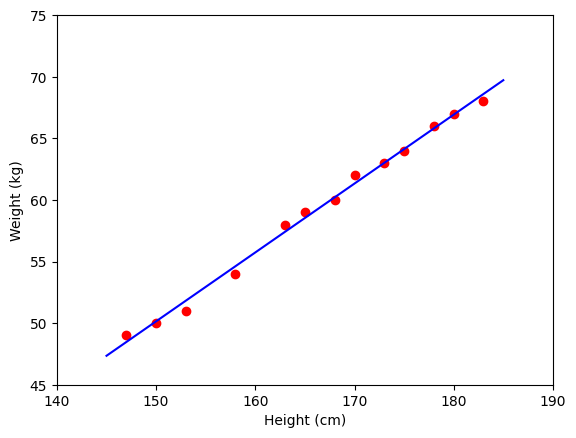

In [ ]:
w_0 = w[0][0]
w_1 = w[1][0]
x0 = np.linspace(145, 185, 2)
y0 = w_0 + w_1*x0

plt.plot(X.T, y.T, 'ro')
plt.plot(x0, y0, 'b')
plt.axis([140, 190, 45, 75])
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.show()

# Theo sklearn


In [ ]:
from sklearn import linear_model
regr = linear_model.LinearRegression(fit_intercept=False)
regr.fit(Xbar, y)
print(f'w = {regr.coef_}')
print(f'w = {w.T}')

w = [[-33.73541021   0.55920496]]
w = [[-33.73541021   0.55920496]]


# Training với Neural Network


In [ ]:
areas = [6.7, 4.6, 3.5, 5.5]
prices = [9.1, 5.9, 4.6, 6.7]
epochs = 10
b = 0.04
w = -0.34
lr = 0.01

## One-sample training


In [ ]:
def predict(X, w, b):
  return w * X + b

# compute gradient
def gradient(y_hat, y, x):
  dw = 2 * x * (y_hat - y)
  db = 2 * (y_hat - y)
  return dw, db

def compute_loss(y_hat, y):
  return (y_hat - y) ** 2

def update_params(w, b, dw, db, lr):
  w = w - lr * dw
  b = b - lr * db
  return w, b


In [ ]:
for epoch in range(epochs):
  for i in range(len(areas)):
    x = areas[i]
    y = prices[i]
    y_hat = predict(x, w, b)
    dw, db = gradient(y_hat, y, x)
    w, b = update_params(w, b, dw, db, lr)
    # print(f'Epoch {epoch}, loss = {compute_loss(y_hat, y)}')

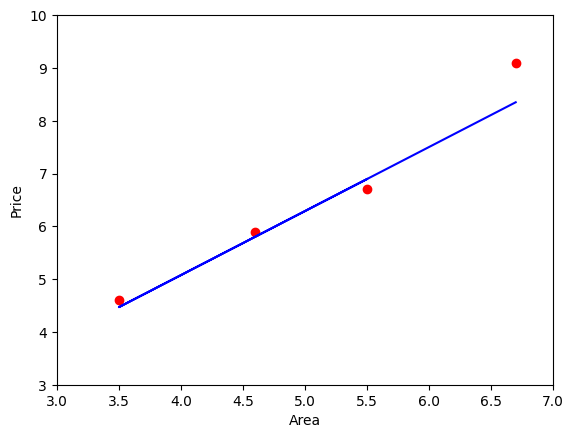

In [ ]:
x0 = np.array(areas)
y0 = w * x0 + b
plt.plot(areas, prices, 'ro')
plt.plot(x0, y0, 'b')
plt.axis([3, 7, 3, 10])
plt.xlabel('Area')
plt.ylabel('Price')
plt.show()

In [ ]:
w

1.2126016661608625

## Mini-batch

In [ ]:
def predict(X, w, b):
  return w * X + b

# compute gradient
def gradient(y_hat, y, x):
  dw = 2 * x * (y_hat - y)
  db = 2 * (y_hat - y)
  return dw, db

def compute_loss(y_hat, y):
  return (y_hat - y) ** 2
def update_params(w, b, dw, db, lr, m):
  w = w - lr * np.sum(dw) / m
  b = b - lr * np.sum(db) / m
  return w, b


In [ ]:
m = 2
for epoch in range(epochs):
  for i in range(len(areas)):
    x = np.array(areas[i: i+m])
    y = np.array(prices[i: i+m])
    y_hat = predict(x, w, b)
    dw, db = gradient(y_hat, y, x)
    w, b = update_params(w, b, dw, db, lr, m)
    i += m

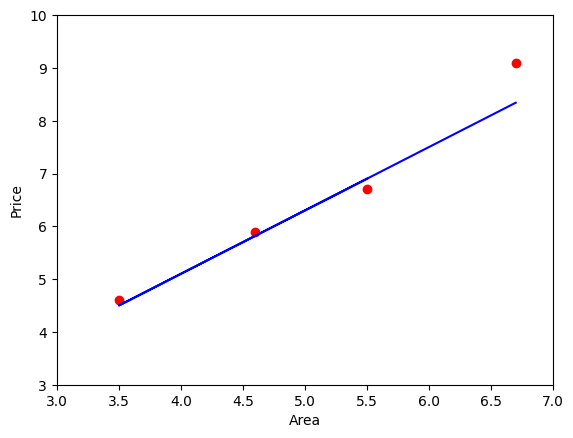

In [ ]:
x0 = np.array(areas)
y0 = w * x0 + b
plt.plot(areas, prices, 'ro')
plt.plot(x0, y0, 'b')
plt.axis([3, 7, 3, 10])
plt.xlabel('Area')
plt.ylabel('Price')
plt.show()

In [ ]:
w

1.2001798979303924

## Basic Exercise

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
advertising_file = '/content/drive/MyDrive/Machine Learning/Linear Regression/Advertising.csv'
df = pd.read_csv(advertising_file)
df = df.drop(['Unnamed: 0'], axis=1)

In [40]:
def get_column(data,index):
  return data.iloc[:, index]

def prepare_data(dataset):
  tv_data = get_column(dataset, 0)
  radio_data = get_column(dataset, 1)
  newspaper_data = get_column(dataset, 2)
  sales_data = get_column(dataset, 3)

  X = np.array([tv_data, radio_data, newspaper_data]).T
  y = np.array(sales_data).T
  return X, y

In [41]:
X, y = prepare_data(df)

In [44]:
len(X[0])

3

In [59]:
# def initialize_params(data_size):
#   w = [random.gauss(mu=0.0, sigma=0.01) for _ in range(data_size)]
#   b = 0
#   return w, b

def initialize_params() :
    w1 , w2 , w3 , b = (0.016992259082509283 , 0.0070783670518262355 ,-0.002307860847821344 , 0)
    return [w1, w2, w3], b
def predict(x, w, b):
  return np.dot(w, x.T) + b

def compute_loss(y_hat, y):
  return (y_hat - y) ** 2

def compute_gradient_wi(xi, y, y_hat):
  return 2 * (y_hat - y) * xi

def compute_gradient_b(y, y_hat):
  return 2 * (y_hat - y)

def update_weight_wi(wi, dw, lr):
  wi = wi - lr * dw
  return wi

def update_bias(b, db, lr):
  b = b - lr * db
  return b

def implement_linear_regression(X, y, epochs=50, lr=1e-5):
  losses = []
  w, b = initialize_params()

  for epoch in range(epochs):
    for i in range(len(X)):
      x = X[i]
      y_hat = predict(x, w, b)
      loss = compute_loss(y_hat, y[i])
      losses.append(loss)
      dw = [compute_gradient_wi(x[j], y[i], y_hat) for j in range(len(x))]
      db = compute_gradient_b(y[i], y_hat)
      w = [update_weight_wi(w[j], dw[j], lr) for j in range(len(w))]
      b = update_bias(b, db, lr)
  return w, b, losses

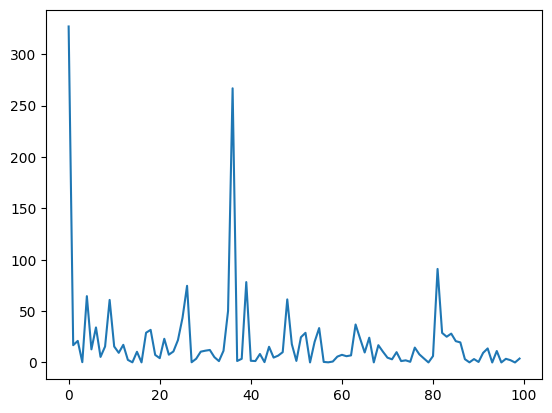

In [60]:
w, b, losses = implement_linear_regression(X, y)
plt.plot(losses[:100])